<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/Kumar_Grokking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================================
# CELL 1: USER PARAMETERS
# Polynomial regression model from Kumar et al., Section 5
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

#Gif generation
import imageio.v2 as imageio
from IPython.display import Image, display

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 1

np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.set_default_dtype(torch.float64)


# ------------------------------------------------------------
# GIF PARAMETERS
# ------------------------------------------------------------
gif_filename = "weight_evolution.gif"
gif_frame_duration = 0.15   # seconds per frame

# Fixed y-limits for all frames so the animation is meaningful
weight_plot_ylim = 5.0


# ============================================================
# PROBLEM PARAMETERS
# ============================================================

# Input dimension x in R^D
D = 2

# Number of training samples.
# Paper Figure 9 uses P = 50, 120, 500.
# P = 120 is the "Goldilocks" example showing grokking.
P_train = 100

# Large independent test set
P_test = 1000

# Number of hidden neurons
N = 20


# ============================================================
# MODEL PARAMETERS
# ============================================================

# Laziness/output scale alpha.
#
# Larger alpha -> more lazy training -> stronger/delayed grokking.
alpha = 4.0

# Quadratic strength epsilon in
#
# phi(h) = h + epsilon/2 * h^2
#
# Smaller epsilon makes the initial NTK less aligned
# with the quadratic target.
epsilon = 0.25


# ============================================================
# TRAINING PARAMETERS
# ============================================================

epochs = 10000000

# Base learning rate.
#
# The actual learning rate will be scaled by 1/alpha^2
# when using the paper's centered-output parameterization.
eta0 = 0.1

learning_rate = eta0 / alpha**2

# Number of points stored for plotting
num_log_points = 100

print(f"D             = {D}")
print(f"P_train       = {P_train}")
print(f"N             = {N}")
print(f"alpha         = {alpha}")
print(f"epsilon       = {epsilon}")
print(f"learning rate = {learning_rate}")

Using device: cpu
D             = 2
P_train       = 100
N             = 20
alpha         = 4.0
epsilon       = 0.25
learning rate = 0.00625


In [15]:
# ============================================================
# CELL 2: DATA
# ============================================================

# Target direction beta_star.
#
# Choose ||beta_star|| = sqrt(D).
# This gives beta_star.x an O(1) scale because
# x ~ N(0, I/D).
# beta_star = torch.randn(D, device=device)
#
#beta_star = ( np.sqrt(D) * beta_star / torch.linalg.vector_norm(beta_star) )

beta_star = torch.ones(D, device=device)

def generate_data(P):
    """
    Generate:
        x ~ N(0, I/D)

    target:
        y(x) = 1/2 (beta_star . x)^2
    """
    X = torch.randn(P, D, device=device) / np.sqrt(D)
    projection = X @ beta_star #alternative to matmul
    y = 0.5 * projection**2

    return X, y


X_train, y_train = generate_data(P_train)
X_test, y_test = generate_data(P_test)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print()
print("Mean target:", y_train.mean().item())
print("Mean target squared:", (y_train**2).mean().item())

X_train shape: torch.Size([100, 2])
y_train shape: torch.Size([100])

Mean target: 0.5586933969307948
Mean target squared: 0.8950466537878785


In [16]:
# ============================================================
# CELL 3: MODEL
# ============================================================

class PolynomialCommitteeMachine(torch.nn.Module):
    def __init__(self, D, N, epsilon, initialization="normal"):
        super().__init__()

        self.epsilon = epsilon

        # -----------------------------
        # Weight initialization
        # -----------------------------

        if initialization == "normal":
            W0 = torch.randn(N, D, device=device)

        elif initialization == "uniform":
            W0 = 2.0 * torch.rand(N, D, device=device) - 1.0

        elif initialization == "small_normal":
            W0 = 0.1 * torch.randn(N, D, device=device)

        elif initialization == "large_normal":
            W0 = 3.0 * torch.randn(N, D, device=device)

        elif initialization == "xavier":
            W0 = torch.empty(N, D, device=device)
            torch.nn.init.xavier_normal_(W0)

        else:
            raise ValueError("Unknown initialization")

        self.W = torch.nn.Parameter(W0)

    def raw_output(self, X):
        h = X @ self.W.T
        phi = h + 0.5 * self.epsilon * h**2
        return phi.mean(dim=1)

#initialization="normal", "small_normal", "large_normal", "uniform", "xavier"
model = PolynomialCommitteeMachine( D=D, N=N, epsilon=epsilon, initialization="small_normal").to(device)


print(model)
print()
print("Number of trainable parameters:",
      sum(p.numel() for p in model.parameters()))

PolynomialCommitteeMachine()

Number of trainable parameters: 40


In [17]:
# ============================================================
# CELL 4: CENTERED PREDICTOR
# ============================================================

# Store the predictor at initialization.
#
# IMPORTANT:
# We detach this from the computational graph.
#
# f_tilde(x,theta) = alpha [ f(x,theta) - f(x,theta_0) ]

with torch.no_grad():

    f0_train = model.raw_output(X_train).detach()

    f0_test = model.raw_output(X_test).detach()


def prediction_train():
    # return alpha * ( model.raw_output(X_train) - f0_train )
    return alpha * model.raw_output(X_train)

def prediction_test():
    # return alpha * ( model.raw_output(X_test) - f0_test )
    return alpha * model.raw_output(X_test)


with torch.no_grad():

    print( "Initial centered train output RMS:", torch.sqrt( torch.mean(prediction_train()**2) ).item() )

Initial centered train output RMS: 0.687925189998049


In [18]:
# ============================================================
# CELL 5: SUMMARY STATISTICS
# ============================================================

def get_summary_statistics():
    W = model.W
    w_bar = W.mean(dim=0)# w_bar
    M = W.T @ W / N # M = (1/N) sum_i w_i w_i^T

    return w_bar, M


def beta_alignment():
    """
    Simple feature-alignment diagnostic:

         beta^T M beta
         -------------
         ||M||_F ||beta beta^T||_F

    This is not exactly the CKA used in every figure,
    but directly tracks the M alignment discussed in
    Sections 5 and 11.
    """

    _, M = get_summary_statistics()

    B = torch.outer(beta_star, beta_star)

    numerator = torch.sum(M * B)

    denominator = ( torch.linalg.matrix_norm(M) * torch.linalg.matrix_norm(B) )

    return (numerator / denominator).item()


def weight_norm():

    return torch.linalg.vector_norm(model.W).item()

In [19]:
# ============================================================
# CELL 6: TRAINING
# ============================================================

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

criterion = torch.nn.MSELoss()


# ------------------------------------------------------------
# Epochs at which quantities are stored
# ------------------------------------------------------------

log_epochs = np.unique(
    np.round(
        np.logspace(
            0,
            np.log10(epochs),
            num_log_points
        )
    ).astype(int)
)

log_epochs = np.concatenate(([0], log_epochs))
log_epochs_set = set(log_epochs.tolist())


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "test_loss": [],
    "weight_norm": [],
    "beta_alignment": []
}

# Store weights for GIF
weight_history = []


def record(epoch):

    with torch.no_grad():

        train_pred = prediction_train()
        test_pred = prediction_test()

        train_loss = criterion(
            train_pred,
            y_train
        ).item()

        test_loss = criterion(
            test_pred,
            y_test
        ).item()

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["weight_norm"].append(weight_norm())
        history["beta_alignment"].append(beta_alignment())

        # Store a COPY of the weights
        weight_history.append(
            model.W.detach().cpu().numpy().flatten().copy()
        )


# ------------------------------------------------------------
# Initial state
# ------------------------------------------------------------

record(0)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

model.train()

for epoch in range(1, epochs + 1):

    # Forward pass
    pred = prediction_train()

    # Loss
    loss = criterion(pred, y_train)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()

    # Update weights
    optimizer.step()

    # Save diagnostics
    if epoch in log_epochs_set:
        record(epoch)

    # Print progress
    if epoch % 5000 == 0:

        print(
            f"epoch = {epoch:7d}  "
            f"train = {history['train_loss'][-1]:.6e}  "
            f"test = {history['test_loss'][-1]:.6e}"
        )


print("Training complete.")

epoch =    5000  train = 1.576973e-02  test = 1.401456e-02
epoch =   10000  train = 5.732067e-03  test = 5.051804e-03
epoch =   15000  train = 2.475726e-03  test = 2.174577e-03
epoch =   20000  train = 1.848404e-03  test = 1.622307e-03
epoch =   25000  train = 1.015762e-03  test = 8.904935e-04
epoch =   30000  train = 7.486395e-04  test = 6.560363e-04
epoch =   35000  train = 5.500185e-04  test = 4.818144e-04
epoch =   40000  train = 4.030186e-04  test = 3.529394e-04
epoch =   45000  train = 4.030186e-04  test = 3.529394e-04
epoch =   50000  train = 2.946287e-04  test = 2.579545e-04
epoch =   55000  train = 2.149722e-04  test = 1.881743e-04
epoch =   60000  train = 2.149722e-04  test = 1.881743e-04
epoch =   65000  train = 1.565940e-04  test = 1.370495e-04
epoch =   70000  train = 1.565940e-04  test = 1.370495e-04
epoch =   75000  train = 1.565940e-04  test = 1.370495e-04
epoch =   80000  train = 1.139121e-04  test = 9.967997e-05
epoch =   85000  train = 1.139121e-04  test = 9.967997e-

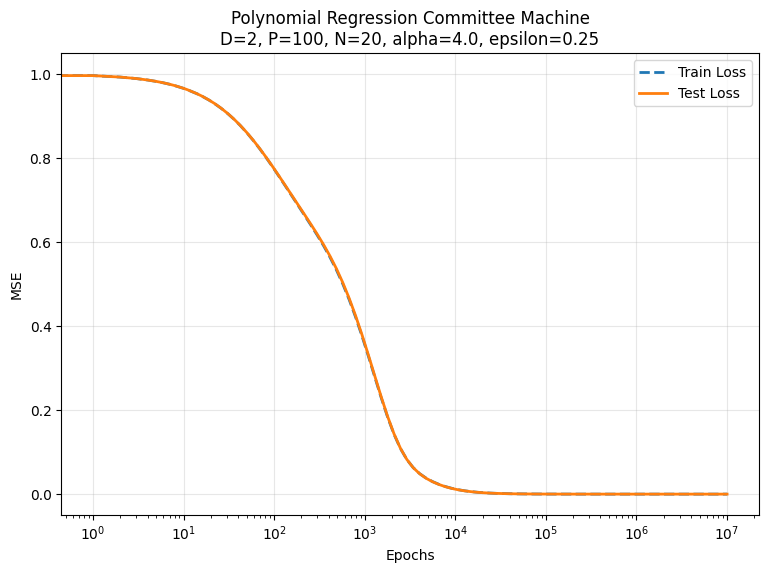

In [20]:
# ============================================================
# CELL 7: TRAIN / TEST LOSS
# ============================================================

epochs_plot = np.array(history["epoch"])

train_loss = np.array(history["train_loss"])
test_loss = np.array(history["test_loss"])

# Normalize by initial value
train_loss = train_loss / train_loss[0]
test_loss = test_loss / test_loss[0]

plt.figure(figsize=(9, 6))
plt.plot( epochs_plot, train_loss, "--", linewidth=2, label="Train Loss" )
plt.plot( epochs_plot, test_loss, linewidth=2, label="Test Loss")
plt.xscale("log")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title(
    f"Polynomial Regression Committee Machine\n"
    f"D={D}, P={P_train}, N={N}, "
    f"alpha={alpha}, epsilon={epsilon}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

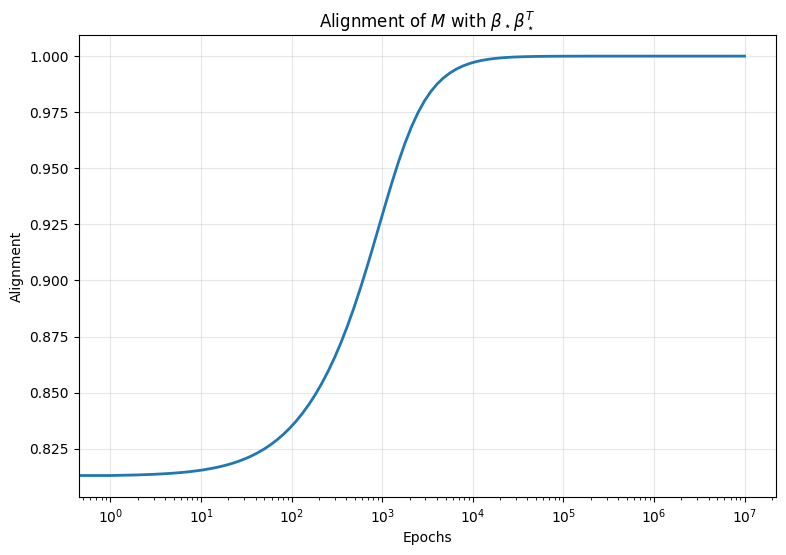

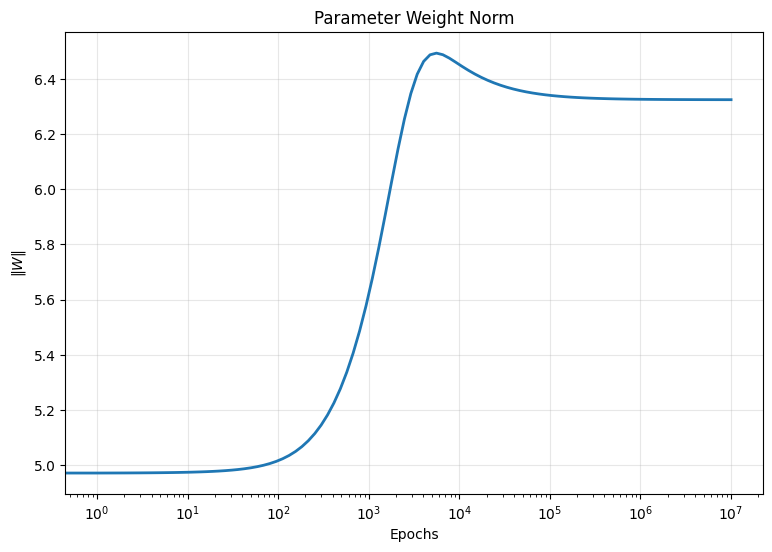

In [21]:
# ============================================================
# CELL 8: FEATURE LEARNING
# ============================================================

alignment = np.array( history["beta_alignment"])
norms = np.array( history["weight_norm"] )

plt.figure(figsize=(9, 6))
plt.plot( epochs_plot, alignment, linewidth=2 )
plt.xscale("log")
plt.xlabel("Epochs")
plt.ylabel("Alignment")
plt.title(
    r"Alignment of $M$ with "
    r"$\beta_\star\beta_\star^T$"
)
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(9, 6))
plt.plot( epochs_plot, norms, linewidth=2 )
plt.xscale("log")
plt.xlabel("Epochs")
plt.ylabel(r"$\|W\|$")
plt.title("Parameter Weight Norm")
plt.grid(alpha=0.3)
plt.show()

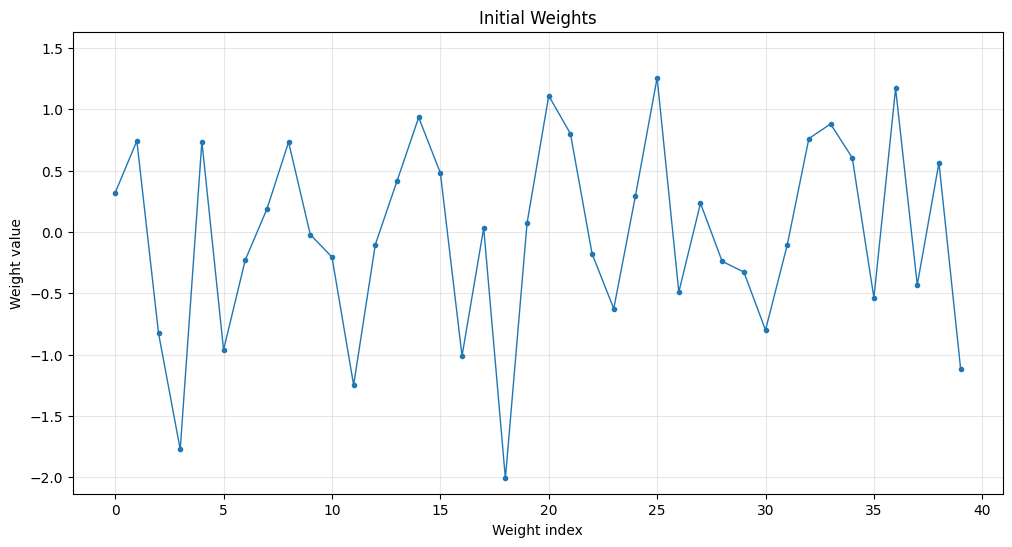

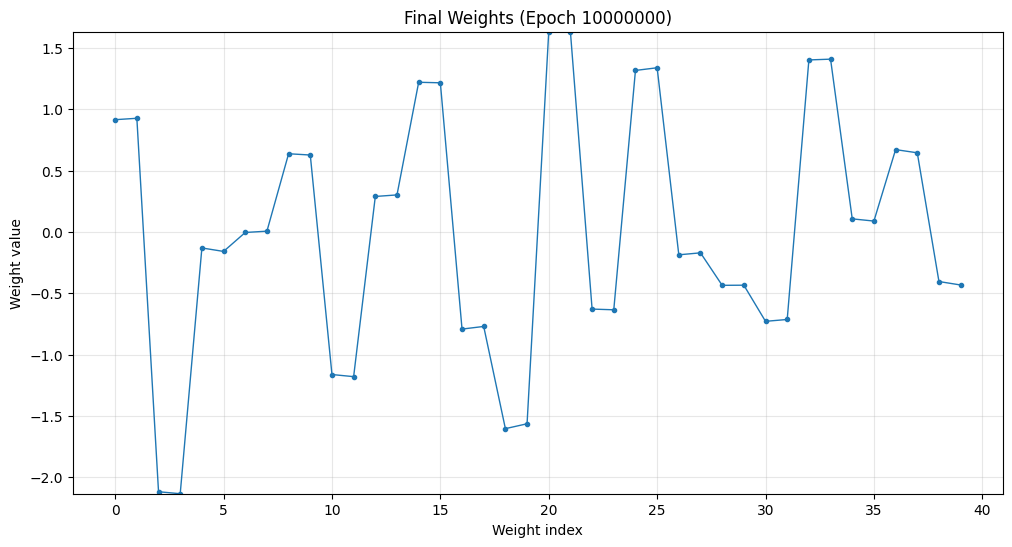

In [22]:
# ============================================================
# CELL 9: INITIAL AND FINAL WEIGHTS AS LINE PLOTS
# ============================================================

W_history = np.array(weight_history)

# Initial and final flattened weights
W_initial = W_history[0]
W_final   = W_history[-1]

# Weight index on x-axis
x = np.arange(len(W_initial))

# Common y-range for both plots
w_min = min(W_initial.min(), W_final.min())
w_max = max(W_initial.max(), W_final.max())

# ------------------------------------------------------------
# Initial weights
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(x, W_initial, marker="o", linewidth=1.0, markersize=3)

plt.xlabel("Weight index")
plt.ylabel("Weight value")
plt.title("Initial Weights")
plt.ylim(w_min, w_max)
plt.grid(alpha=0.3)

plt.show()


# ------------------------------------------------------------
# Final weights
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(x, W_final, marker="o", linewidth=1.0, markersize=3)

plt.xlabel("Weight index")
plt.ylabel("Weight value")
plt.title(f"Final Weights (Epoch {history['epoch'][-1]})")
plt.ylim(w_min, w_max)
plt.grid(alpha=0.3)

plt.show()

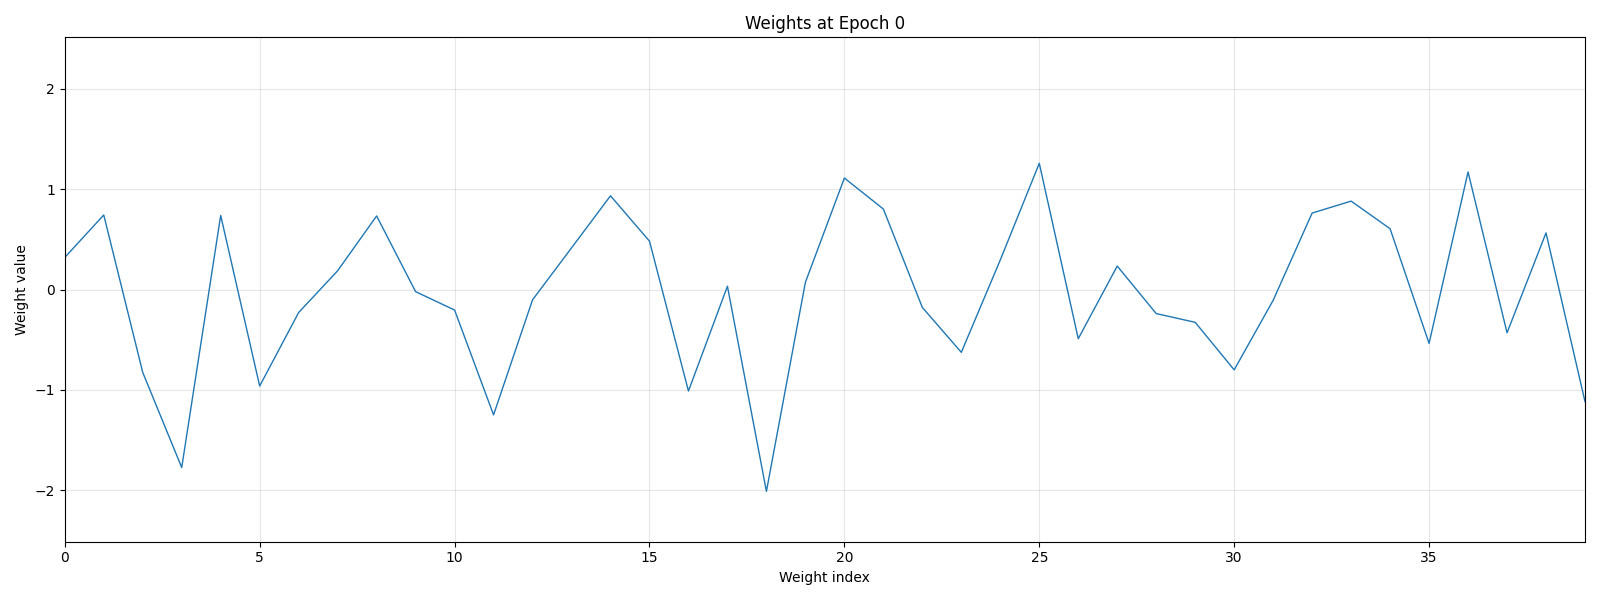

In [23]:
# ============================================================
# CELL 10: CREATE WEIGHT-EVOLUTION GIF (LINE PLOT)
# ============================================================

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Convert stored weights to one array
# Shape: (num_frames, num_weights)
W_history = np.array(weight_history)

# Epochs corresponding to saved weights
epoch_history = np.array(history["epoch"])

# Common y-axis range for all frames
max_weight = np.max(np.abs(W_history))

# x-axis = weight index
x = np.arange(W_history.shape[1])

# ------------------------------------------------------------
# Create figure once
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 6))

line, = ax.plot(x, W_history[0], linewidth=1.0)

ax.set_xlabel("Weight index")
ax.set_ylabel("Weight value")

ax.set_xlim(0, W_history.shape[1] - 1)
ax.set_ylim(-1.05 * max_weight, 1.05 * max_weight)

ax.grid(alpha=0.3)

title = ax.set_title(f"Weights at Epoch {epoch_history[0]}")

fig.tight_layout()

# ------------------------------------------------------------
# Update function
# ------------------------------------------------------------

def update(frame):
    line.set_ydata(W_history[frame])
    title.set_text(f"Weights at Epoch {epoch_history[frame]}")
    return line,

# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

animation = FuncAnimation(
    fig,
    update,
    frames=len(W_history),
    interval=100,
    blit=True
)

gif_filename = "weight_evolution_line.gif"

animation.save(
    gif_filename,
    writer=PillowWriter(fps=10)
)

plt.close(fig)

display(Image(filename=gif_filename))

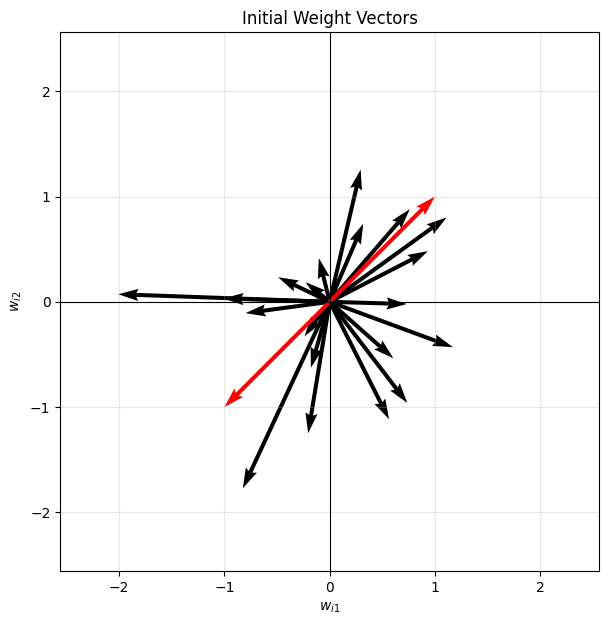

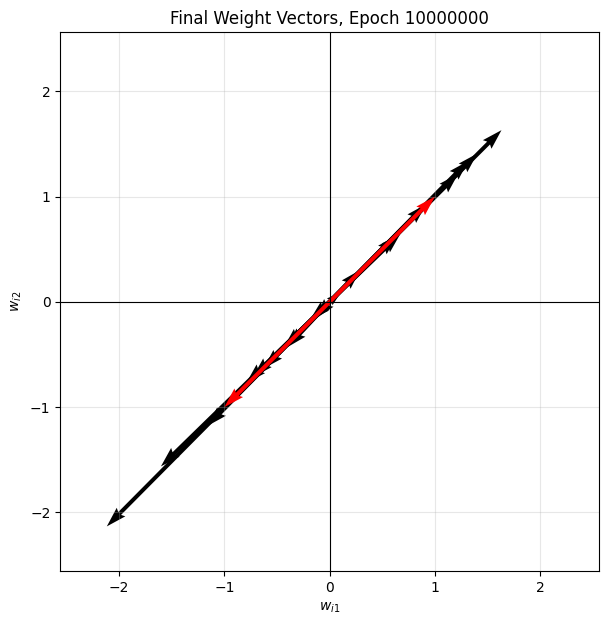

In [24]:
# ============================================================
# CELL 11: PLOT ALL WEIGHT VECTORS IN 2D
# ============================================================

W_initial = np.array(weight_history[0]).reshape(N, D)
W_final   = np.array(weight_history[-1]).reshape(N, D)

beta = beta_star.detach().cpu().numpy()

# Common axis limit
max_value = max(
    np.max(np.abs(W_initial)),
    np.max(np.abs(W_final)),
    np.max(np.abs(beta))
)

limit = 1.2 * max_value


# ------------------------------------------------------------
# Initial weights
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.quiver(
    np.zeros(N),
    np.zeros(N),
    W_initial[:, 0],
    W_initial[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.quiver(
    0, 0,
    beta[0], beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)

plt.quiver(
    0, 0,
    -beta[0], -beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)

plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.xlabel(r"$w_{i1}$")
plt.ylabel(r"$w_{i2}$")
plt.title("Initial Weight Vectors")

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.grid(alpha=0.3)
plt.gca().set_aspect("equal")

plt.show()


# ------------------------------------------------------------
# Final weights
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.quiver(
    np.zeros(N),
    np.zeros(N),
    W_final[:, 0],
    W_final[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.quiver(
    0, 0,
    beta[0], beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)

plt.quiver(
    0, 0,
    -beta[0], -beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)

plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.xlabel(r"$w_{i1}$")
plt.ylabel(r"$w_{i2}$")
plt.title(f"Final Weight Vectors, Epoch {history['epoch'][-1]}")

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.grid(alpha=0.3)
plt.gca().set_aspect("equal")

plt.show()

In [25]:
# ============================================================
# CELL 12: MOVIE OF WEIGHT VECTORS + WEIGHT NORM
# ============================================================

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display


# ------------------------------------------------------------
# Stored training history
# ------------------------------------------------------------

# Shape: (number of saved epochs, N, D)
W_history = np.array(weight_history).reshape(-1, N, D)

epoch_history = np.array(history["epoch"])

norm_history = np.array(history["weight_norm"])

beta = beta_star.detach().cpu().numpy()


# ------------------------------------------------------------
# Axis limits for weight-vector plot
# ------------------------------------------------------------

max_value = max(
    np.max(np.abs(W_history)),
    np.max(np.abs(beta))
)

limit = 1.2 * max_value


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6)
)


# ============================================================
# LEFT: WEIGHT VECTORS
# ============================================================

weight_arrows = ax1.quiver(
    np.zeros(N),
    np.zeros(N),
    W_history[0, :, 0],
    W_history[0, :, 1],
    angles="xy",
    scale_units="xy",
    scale=1
)


# + beta_star
ax1.quiver(
    0, 0,
    beta[0], beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)


# - beta_star
ax1.quiver(
    0, 0,
    -beta[0], -beta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red"
)


ax1.set_xlim(-limit, limit)
ax1.set_ylim(-limit, limit)

ax1.set_xlabel(r"$w_{i1}$")
ax1.set_ylabel(r"$w_{i2}$")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.axvline(0, color="black", linewidth=0.8)

ax1.grid(alpha=0.3)
ax1.set_aspect("equal")

title = ax1.set_title(
    f"Weight Vectors, Epoch {epoch_history[0]}"
)


# ============================================================
# RIGHT: WEIGHT NORM
# ============================================================

norm_line, = ax2.plot(
    [],
    [],
    linewidth=2
)

current_point, = ax2.plot(
    [],
    [],
    marker="o",
    markersize=7
)

ax2.set_xlim(
    epoch_history[0],
    epoch_history[-1]
)

ax2.set_ylim(
    0.95 * np.min(norm_history),
    1.05 * np.max(norm_history)
)

ax2.set_xscale("symlog", linthresh=1)

ax2.set_xlabel("Epoch")
ax2.set_ylabel(r"$\|W\|_F$")
ax2.set_title("Weight Norm During Training")

ax2.grid(alpha=0.3)


# Text showing numerical value
norm_text = ax2.text(
    0.05,
    0.95,
    f"Norm = {norm_history[0]:.4f}",
    transform=ax2.transAxes,
    verticalalignment="top"
)


# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(frame):

    # --------------------------------------------------------
    # Update weight vectors
    # --------------------------------------------------------

    W = W_history[frame]

    weight_arrows.set_UVC(
        W[:, 0],
        W[:, 1]
    )

    title.set_text(
        f"Weight Vectors, Epoch {epoch_history[frame]}"
    )


    # --------------------------------------------------------
    # Update norm curve
    # --------------------------------------------------------

    norm_line.set_data(
        epoch_history[:frame + 1],
        norm_history[:frame + 1]
    )

    current_point.set_data(
        [epoch_history[frame]],
        [norm_history[frame]]
    )

    norm_text.set_text(
        f"Norm = {norm_history[frame]:.4f}"
    )


    return (
        weight_arrows,
        norm_line,
        current_point,
        norm_text
    )


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    update,
    frames=len(W_history),
    interval=100,
    blit=False
)


# ============================================================
# SAVE AND DISPLAY MOVIE
# ============================================================

from matplotlib.animation import FFMpegWriter
from IPython.display import Video

movie_filename = "weight_vectors_and_norm.mp4"

animation.save(
    movie_filename,
    writer=FFMpegWriter(fps=10)
)

plt.close(fig)

Video(movie_filename, embed=True)

In [26]:
from google.colab import files
files.download("weight_vectors_and_norm.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>